# Simulation and parameter recovery of dynamic foraging task.

In [1]:
pip install -e /root/capsule

Obtaining file:///root/capsule
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for aind-dynamic-foraging-models (pyproject.toml) ... done
  Created wheel for aind-dynamic-foraging-models: filename=aind_dynamic_foraging_models-0.13.0-0.editable-py3-none-any.whl size=6692 sha256=2556329ee6baf668be59c61ef3de4ed666b9f1ea789e11d3259b7f3be738ef34
  Stored in directory: /tmp/pip-ephem-wheel-cache-cd4ilksw/wheels/e3/8f/f4/ca91d283f9cf1779655f765432c0871dffb626f70fabd09288
Successfully built aind-dynamic-foraging-models
  Attempting uninstall: aind-dynamic-foraging-models
    Found existing installation: aind-dynamic-foraging-models 0.13.0
    Uninstalling aind-dynamic-foraging-models-0.13.0:
      Successfully uninstalled aind-dynamic-foraging-models-0.13.0
Note: you may need to restart the kernel to use updated pack

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from aind_behavior_gym.dynamic_foraging.task import CoupledBlockTask, UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model import ForagerCollection

## Get all foragers

In [1]:
from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection


forager_collection: ForagerCollection = ForagerCollection()
df = forager_collection.get_all_foragers()
df.columns

Index(['agent_class_name', 'agent_kwargs', 'agent_alias',
       'number_of_learning_rate', 'number_of_forget_rate', 'choice_kernel',
       'action_selection', 'preset_name', 'n_free_params', 'params', 'forager',
       'win_stay_lose_switch', 'reset_to_threshold', 'include_stay_bias',
       'fix_threshold'],
      dtype='object')

In [9]:

n=59
print(df['agent_alias'][n])
print(df['params'][n])
print(df['n_free_params'][n])


ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_FixThrF
$\alpha_{rew}$, $\alpha_{unr}$, $b_L$, $\beta$, $\rho$, $b_{stay}$
6


In [3]:
df['agent_alias'][77]

'ForagingCompareThreshold_L2_CKfull_ResetF_StayBiasF_FixThrF'

In [3]:
df

,agent_class_name,agent_kwargs,agent_alias,number_of_learning_rate,number_of_forget_rate,choice_kernel,action_selection,preset_name,n_free_params,params,forager,win_stay_lose_switch,reset_to_threshold,include_stay_bias,fix_threshold
0,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_softmax,1.0,0.0,none,softmax,None,3,"$\alpha$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN
1,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_epsi,1.0,0.0,none,epsilon-greedy,Rescorla-Wagner,3,"$\alpha$, $b_L$, $\epsilon$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN
2,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_softmax,1.0,0.0,one_step,softmax,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN
3,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CK1_epsi,1.0,0.0,one_step,epsilon-greedy,None,4,"$\alpha$, $\alpha_{ck}$ (fixed), $w_{ck}$, $b_...",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN
4,ForagerQLearning,"{'number_of_learning_rate': 1, 'number_of_forg...",QLearning_L1F0_CKfull_softmax,1.0,0.0,full,softmax,None,5,"$\alpha$, $\alpha_{ck}$, $w_{ck}$, $b_L$, $\beta$",<aind_dynamic_foraging_models.generative_model...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetT_Stay...,2.0,NaN,full,NaN,None,7,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,True,False,False
74,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,7,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,True,True
75,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,8,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,True,False
76,ForagerCompareThreshold,"{'number_of_learning_rate': 2, 'choice_kernel'...",ForagingCompareThreshold_L2_CKfull_ResetF_Stay...,2.0,NaN,full,NaN,None,6,"$\alpha_{rew}$, $\alpha_{unr}$, $\alpha_{ck}$,...",<aind_dynamic_foraging_models.generative_model...,NaN,False,False,True


## Parameter Recovery

2026-02-24 06:58:02,020 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...


=== Ground-truth generator ===
agent_alias: ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_FixThrF
agent_kwargs: {'number_of_learning_rate': 2, 'choice_kernel': 'none', 'reset_to_threshold': False, 'include_stay_bias': True, 'fix_threshold': False, 'threshold_fixed': None}
params_list_free: ['biasL', 'learn_rate_rew', 'threshold', 'softmax_inverse_temperature', 'learn_rate_unrew', 'stay_bias']
params: {'learn_rate_rew': 0.32, 'learn_rate_unrew': 0.24, 'threshold': 0.6, 'softmax_inverse_temperature': 10.0, 'biasL': 3.0, 'stay_bias': 1.5}

Fitting variant: L1 | reset_to_threshold=True
differential_evolution step 1: f(x)= 288.73291289690644
differential_evolution step 2: f(x)= 258.21225466316594
differential_evolution step 3: f(x)= 257.15392051255265
differential_evolution step 4: f(x)= 257.15392051255265
differential_evolution step 5: f(x)= 256.98171407578786
differential_evolution step 6: f(x)= 256.53840052807163
differential_evolution step 7: f(x)= 256.53840052807163
differential_

2026-02-24 06:58:09,924 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L1 | reset_to_threshold=False
differential_evolution step 1: f(x)= 319.64286741242955
differential_evolution step 2: f(x)= 318.673971300385
differential_evolution step 3: f(x)= 263.89930733422153
differential_evolution step 4: f(x)= 235.75444627568817
differential_evolution step 5: f(x)= 235.75444627568817
differential_evolution step 6: f(x)= 235.75444627568817
differential_evolution step 7: f(x)= 235.75444627568817
differential_evolution step 8: f(x)= 228.52074447817893
differential_evolution step 9: f(x)= 228.52074447817893
differential_evolution step 10: f(x)= 227.90063497870568
differential_evolution step 11: f(x)= 226.61014749398615
differential_evolution step 12: f(x)= 226.60400096888696
differential_evolution step 13: f(x)= 226.40140586936693
differential_evolution step 14: f(x)= 226.21743109218423
differential_evolution step 15: f(x)= 226.1206336521529
differential_evolution step 16: f(x)= 226.0624421818566
differential_evolution step 17: f(x)= 226.06244218185

2026-02-24 06:58:17,199 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L2 | reset_to_threshold=True
differential_evolution step 1: f(x)= 307.59366855409803
differential_evolution step 2: f(x)= 307.59366855409803
differential_evolution step 3: f(x)= 307.59366855409803
differential_evolution step 4: f(x)= 271.3739354235124
differential_evolution step 5: f(x)= 259.9400205064759
differential_evolution step 6: f(x)= 259.9400205064759
differential_evolution step 7: f(x)= 259.9400205064759
differential_evolution step 8: f(x)= 259.8554909853051
differential_evolution step 9: f(x)= 259.8554909853051
differential_evolution step 10: f(x)= 259.4300658040454
differential_evolution step 11: f(x)= 256.51320340867727
differential_evolution step 12: f(x)= 253.73201244060664
differential_evolution step 13: f(x)= 253.73201244060664
differential_evolution step 14: f(x)= 253.73201244060664
differential_evolution step 15: f(x)= 253.73201244060664
differential_evolution step 16: f(x)= 253.73201244060664
differential_evolution step 17: f(x)= 253.73201244060664


2026-02-24 06:58:33,081 - aind_dynamic_foraging_models.generative_model.base - INFO - Fitting the model using the whole dataset...



Fitting variant: L2 | reset_to_threshold=False
differential_evolution step 1: f(x)= 294.51636317776274
differential_evolution step 2: f(x)= 278.42415056106825
differential_evolution step 3: f(x)= 245.99425097286365
differential_evolution step 4: f(x)= 245.99425097286365
differential_evolution step 5: f(x)= 245.99425097286365
differential_evolution step 6: f(x)= 237.5903913216573
differential_evolution step 7: f(x)= 237.5903913216573
differential_evolution step 8: f(x)= 237.5903913216573
differential_evolution step 9: f(x)= 237.5903913216573
differential_evolution step 10: f(x)= 228.1465219572567
differential_evolution step 11: f(x)= 228.1465219572567
differential_evolution step 12: f(x)= 228.1465219572567
differential_evolution step 13: f(x)= 228.1465219572567
differential_evolution step 14: f(x)= 228.1465219572567
differential_evolution step 15: f(x)= 228.1465219572567
differential_evolution step 16: f(x)= 228.1465219572567
differential_evolution step 17: f(x)= 228.1465219572567
diff

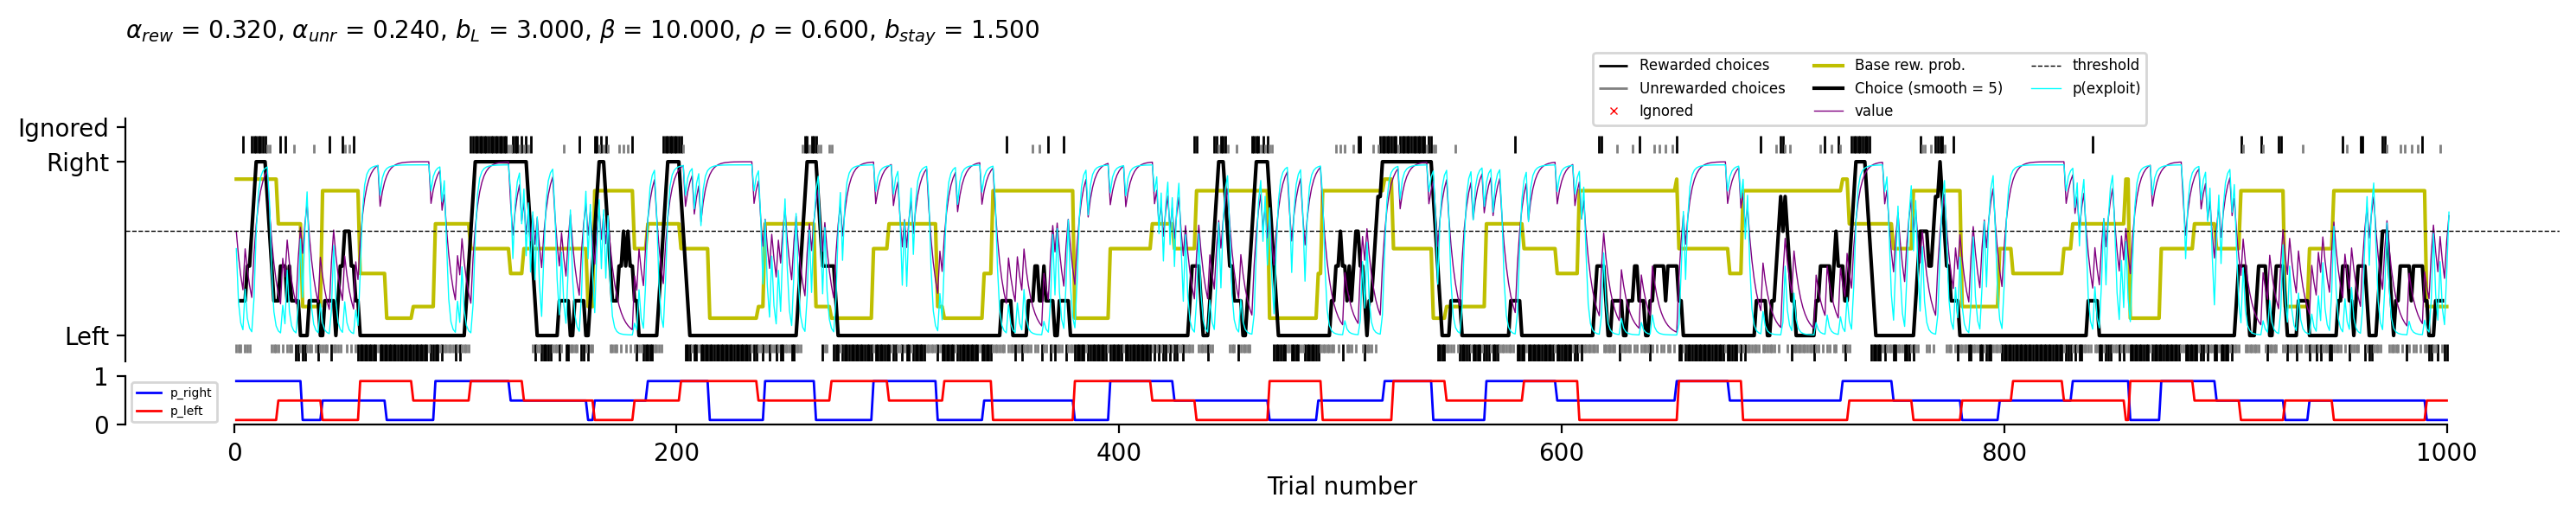

In [ ]:
"""
Compare model-recovery across 4 variants of ForagerCompareThreshold:

1) L1 + Reset
2) L1 + NoReset
3) L2 + Reset
4) L2 + NoReset

We:
- Generate ONE synthetic dataset from a chosen "ground-truth" variant
- Fit all 4 variants to that same dataset
- Compare: LPT, prediction accuracy, fitted params vs ground truth (where comparable)

PLUS:
- Plot sessions for ALL fitted variants (and the generator) using plot_session(if_plot_latent=True)

IMPORTANT:
- reset_to_threshold and number_of_learning_rate are hyperparameters -> agent_kwargs (NOT set_params)
- For fitting, you must instantiate the fitting agent with matching agent_kwargs;
  otherwise the parameter list / bounds won't match the model structure.
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from aind_behavior_gym.dynamic_foraging.task.uncoupled_block_task import UncoupledBlockTask
from aind_dynamic_foraging_models.generative_model.foragers import ForagerCollection


def _build_ctt_agent(
    *,
    number_of_learning_rate: int,
    reset_to_threshold: bool,
    choice_kernel: str = "none",
    include_stay_bias: bool = False,
    fix_threshold: bool = False,
    threshold_fixed: float | None = None,
    seed: int = 42,
):
    """Build a CompareToThreshold agent with explicit agent_kwargs (hyperparameters)."""
    fc = ForagerCollection()
    preset = fc.FORAGER_PRESETS["CompareToThreshold"]
    agent_class_name = preset["agent_class"]

    agent_kwargs = dict(preset["agent_kwargs"])  # copy
    agent_kwargs.update(
        dict(
            number_of_learning_rate=number_of_learning_rate,
            reset_to_threshold=reset_to_threshold,
            choice_kernel=choice_kernel,
            include_stay_bias=bool(include_stay_bias),
            fix_threshold=bool(fix_threshold),
            threshold_fixed=(float(threshold_fixed) if threshold_fixed is not None else None),
        )
    )

    agent = fc.get_forager(agent_class_name, agent_kwargs=agent_kwargs, seed=seed)
    return agent


def _set_ground_truth_params(
    agent,
    *,
    threshold=0.2,
    beta=10.0,
    biasL=3.0,
    lr_rew=0.32,
    lr_unrew=0.24,
    lr=0.28,
    stay_bias=0.0,
):
    """
    Set ground-truth parameters depending on model structure.

    - Automatically handles L1 vs L2 learning-rate structure.
    - Automatically adds stay_bias only if include_stay_bias=True.
    - Automatically skips threshold if fix_threshold=True.
    """

    n_lr = int(agent.agent_kwargs.get("number_of_learning_rate", 1))
    include_stay_bias = bool(agent.agent_kwargs.get("include_stay_bias", False))
    fix_threshold = bool(agent.agent_kwargs.get("fix_threshold", False))

    # Base parameters common to all variants
    param_dict = dict(
        softmax_inverse_temperature=float(beta),
        biasL=float(biasL),
    )

    # Threshold (only if learnable)
    if not fix_threshold:
        param_dict["threshold"] = float(threshold)
    else:
        # If fixed, set it via agent_kwargs instead
        agent.agent_kwargs["threshold_fixed"] = float(threshold)

    # Learning rate structure
    if n_lr == 1:
        param_dict["learn_rate"] = float(lr)
    elif n_lr == 2:
        param_dict["learn_rate_rew"] = float(lr_rew)
        param_dict["learn_rate_unrew"] = float(lr_unrew)
    else:
        raise ValueError(f"number_of_learning_rate must be 1 or 2, got {n_lr}")

    # Stay bias (only if included in model structure)
    if include_stay_bias:
        param_dict["stay_bias"] = float(stay_bias)

    agent.set_params(**param_dict)


def _fit_agent_on_data(
    *,
    number_of_learning_rate: int,
    reset_to_threshold: bool,
    include_stay_bias: bool,
    fix_threshold: bool,
    choice_history,
    reward_history,
    seed: int = 42,
    workers: int = 4,
    # Optional: if fix_threshold=True, use this fixed value (defaults to 0.4 if None)
    threshold_fixed: float | None = None,
):
    """Fit one variant to the same dataset and return summary dict + fitted agent.

    Notes
    -----
    - include_stay_bias / fix_threshold are *hyperparameters* (agent_kwargs), not fitted params.
    - If fix_threshold=True, we must pass `threshold_fixed` through agent_kwargs so the agent
      constructor does not raise (it requires threshold_fixed or params['threshold']).
    - We do NOT need to pass threshold as a fitted param when fix_threshold=True.
    """
    if fix_threshold and (threshold_fixed is None):
        # Choose a default fixed threshold. If you want to match the generator,
        # pass threshold_fixed=float(ground_truth_params["threshold"]) from the caller.
        threshold_fixed = 0.4

    agent = _build_ctt_agent(
        number_of_learning_rate=number_of_learning_rate,
        reset_to_threshold=reset_to_threshold,
        include_stay_bias=include_stay_bias,
        fix_threshold=fix_threshold,
        threshold_fixed=threshold_fixed,
        seed=seed,
    )

    agent.fit(
        choice_history,
        reward_history,
        clamp_params={},
        DE_kwargs=dict(
            workers=workers,
            disp=True,
            seed=np.random.default_rng(seed),
        ),
        k_fold_cross_validation=None,
    )

    fr = agent.fitting_result
    fit_names = fr.fit_settings["fit_names"]
    fitted = dict(zip(fit_names, fr.x))

    return dict(
        number_of_learning_rate=number_of_learning_rate,
        reset_to_threshold=reset_to_threshold,
        include_stay_bias=include_stay_bias,
        fix_threshold=fix_threshold,
        threshold_fixed=threshold_fixed,
        agent_alias=agent.get_agent_alias(),
        fit_names=fit_names,
        fitted_params=fitted,
        LPT=float(fr.LPT),
        prediction_accuracy=float(fr.prediction_accuracy),
        agent=agent,  # <-- keep the fitted agent so we can plot_session()
    )

def _run_agent_on_observed_history(agent, choice_history, reward_history):
    """
    Run the agent forward on the *observed* (choice, reward) history to populate
    latent variables for plotting.

    Assumes the base class supports stepping through data via perform(...),
    but since we already have histories, we use the agent's fit/predict pipeline if available.

    Fallback:
    - If your base class provides something like agent.run_on_history(...) use that instead.
    - Otherwise, we use `agent.predict(choice_history, reward_history)` if it exists.
    """
    if hasattr(agent, "predict"):
        agent.predict(choice_history, reward_history)
        return

    # If there is no predict(), we try a light fallback by manually setting histories.
    # Many codebases store them during fit; in that case this is a no-op.
    if hasattr(agent, "choice_history"):
        agent.choice_history = np.asarray(choice_history, dtype=int)
    if hasattr(agent, "reward_history"):
        agent.reward_history = np.asarray(reward_history, dtype=float)

    # If plot_session relies on internal computed arrays (choice_prob/value/etc),
    # and these aren't filled by fit(), you'll need a real replay method in the base class.
    # In that case, replace this with the correct call in your codebase.


# =============================================================================
# 1) Generate ONE synthetic dataset from a chosen ground-truth variant
# =============================================================================

# Pick your ground-truth generating model here:
GT_number_of_learning_rate = 2     # 1 or 2
GT_reset_to_threshold = False      # True or False
GT_include_stay_bias = True        # <-- add this

task = UncoupledBlockTask(
    reward_baiting=False,
    num_trials=1000,
    seed=53,
)

forager_gen = _build_ctt_agent(
    number_of_learning_rate=GT_number_of_learning_rate,
    reset_to_threshold=GT_reset_to_threshold,
    include_stay_bias=GT_include_stay_bias,   # <-- add this
    seed=42,
)

# Set ground-truth params (choose values you want)
_set_ground_truth_params(
    forager_gen,
    threshold=0,
    beta=10.0,
    biasL=3.0,
    lr_rew=0.32,
    lr_unrew=0.24,
    lr=0.15,      # used only if GT is L1
    stay_bias=1.5 # <-- add this
)

print("=== Ground-truth generator ===")
print("agent_alias:", forager_gen.get_agent_alias())
print("agent_kwargs:", forager_gen.agent_kwargs)
print("params_list_free:", forager_gen.params_list_free)
print("params:", forager_gen.params.model_dump())

# Run generator
forager_gen.perform(task)
# Plot generator session
fig_gen, axes_gen = forager_gen.plot_session(if_plot_latent=True)



ground_truth_params = forager_gen.params.model_dump()

choice_history = forager_gen.get_choice_history()
reward_history = forager_gen.get_reward_history()



# =============================================================================
# 2) Fit all 4 variants to the SAME dataset
# =============================================================================

variants = [
    dict(number_of_learning_rate=1, reset_to_threshold=True, include_stay_bias=True,fix_threshold=True),
    dict(number_of_learning_rate=1, reset_to_threshold=False, include_stay_bias=True,fix_threshold=True),
    dict(number_of_learning_rate=2, reset_to_threshold=True, include_stay_bias=True,fix_threshold=True),
    dict(number_of_learning_rate=2, reset_to_threshold=False, include_stay_bias=True,fix_threshold=True),
]

results = []
for v in variants:
    print("\n" + "=" * 80)
    print(f"Fitting variant: L{v['number_of_learning_rate']} | reset_to_threshold={v['reset_to_threshold']}")
    out = _fit_agent_on_data(
        number_of_learning_rate=v["number_of_learning_rate"],
        reset_to_threshold=v["reset_to_threshold"],
        include_stay_bias=v["include_stay_bias"],
        fix_threshold=v["fix_threshold"],
        choice_history=choice_history,
        reward_history=reward_history,
        seed=42,
        workers=4,
    )
    results.append(out)




In [25]:
agent.get_fitting_result_dict()['fit_settings']

{'fit_choice_history': [0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0

In [ ]:
agent.get_fitting_result_dict().keys()

dict_keys(['fit_settings', 'params', 'log_likelihood', 'AIC', 'BIC', 'LPT', 'LPT_AIC', 'LPT_BIC', 'k_model', 'n_trials', 'nfev', 'nit', 'success', 'population', 'population_energies', 'params_without_polishing', 'log_likelihood_without_polishing', 'prediction_accuracy', 'fitted_latent_variables'])

In [22]:
dir(agent)

['ParamFitBoundModel',
 'ParamModel',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cost_func_for_DE',
 '_fitting_result_to_dict',
 '_get_alpha_for_trial',
 '_get_params_list',
 '_get_params_model',
 '_get_stay_bias_value',
 '_get_threshold_value',
 '_optimize_DE',
 '_reset',
 'act',
 'agent_kwargs',
 'choice_history',
 'choice_kernel',
 'choice_prob',
 'current_option',
 'exploiting',
 'fit',
 'fitting_result',
 'fitting_result_cross_validation',
 'get_agent_alias',
 'get_choice_history',
 'get_fitting_result_dict',
 'get_latent_variables',
 'get_p_reward',
 'get_params',
 'get_params_str',
 'get_reward_history',
 'learn',
 'load',
 'n_actions',
 


================ GROUND TRUTH ================

Ground-truth agent: ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_FixThrF
Ground-truth params: {'learn_rate_rew': 0.32, 'learn_rate_unrew': 0.24, 'threshold': 0.6, 'softmax_inverse_temperature': 10.0, 'biasL': 3.0, 'stay_bias': 1.5}



--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasT_FixThrT0.40

--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L1_CKnone_ResetF_StayBiasT_FixThrT0.40

--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L2_CKnone_ResetT_StayBiasT_FixThrT0.40

--------------------------------------------------------------------------------
Plotting fitted variant: ForagingCompareThreshold_L2_CKnone_ResetF_StayBiasT_FixThrT0.40


,agent_alias,number_of_learning_rate,reset_to_threshold,LPT,prediction_accuracy,Fit_biasL,Fit_learn_rate,Fit_learn_rate_rew,Fit_learn_rate_unrew,Fit_softmax_inverse_temperature,Fit_stay_bias
0,GROUND_TRUTH,2,False,NaN,NaN,3.000000,NaN,0.320000,0.240000,10.000000,1.500000
1,ForagingCompareThreshold_L2_CKnone_ResetF_Stay...,2,False,0.798905,0.902,3.353542,NaN,0.377035,0.255556,9.007199,-0.929317
2,ForagingCompareThreshold_L1_CKnone_ResetF_Stay...,1,False,0.798187,0.895,3.314954,0.301525,NaN,NaN,9.815418,-0.066947
3,ForagingCompareThreshold_L2_CKnone_ResetT_Stay...,2,True,0.781298,0.878,3.630767,NaN,0.342258,0.210229,9.066244,-1.635340
4,ForagingCompareThreshold_L1_CKnone_ResetT_Stay...,1,True,0.778765,0.878,3.726674,0.224592,NaN,NaN,10.403007,-1.161852


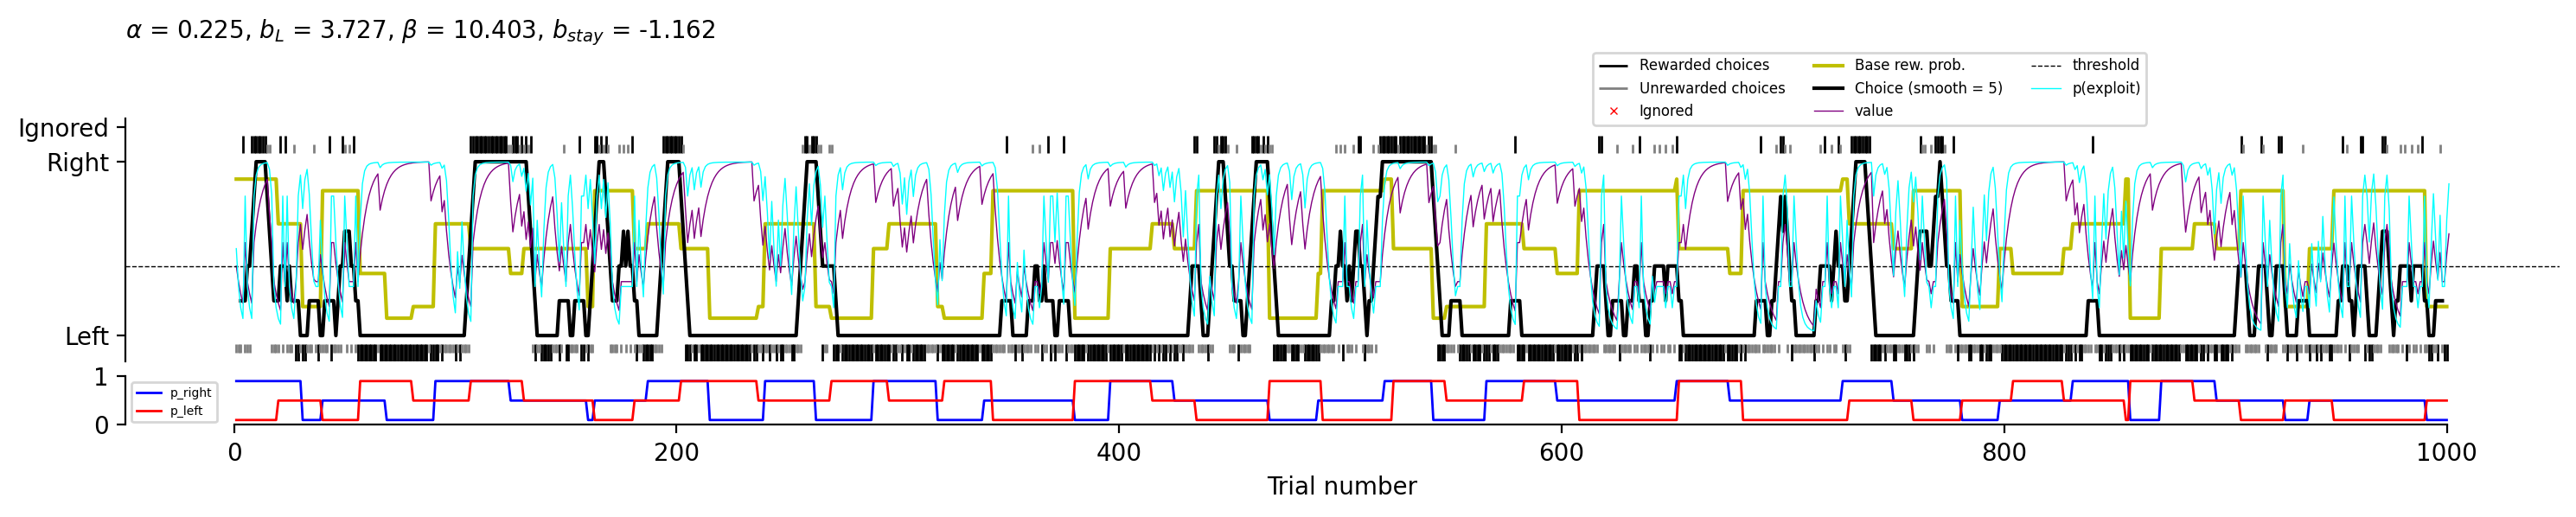

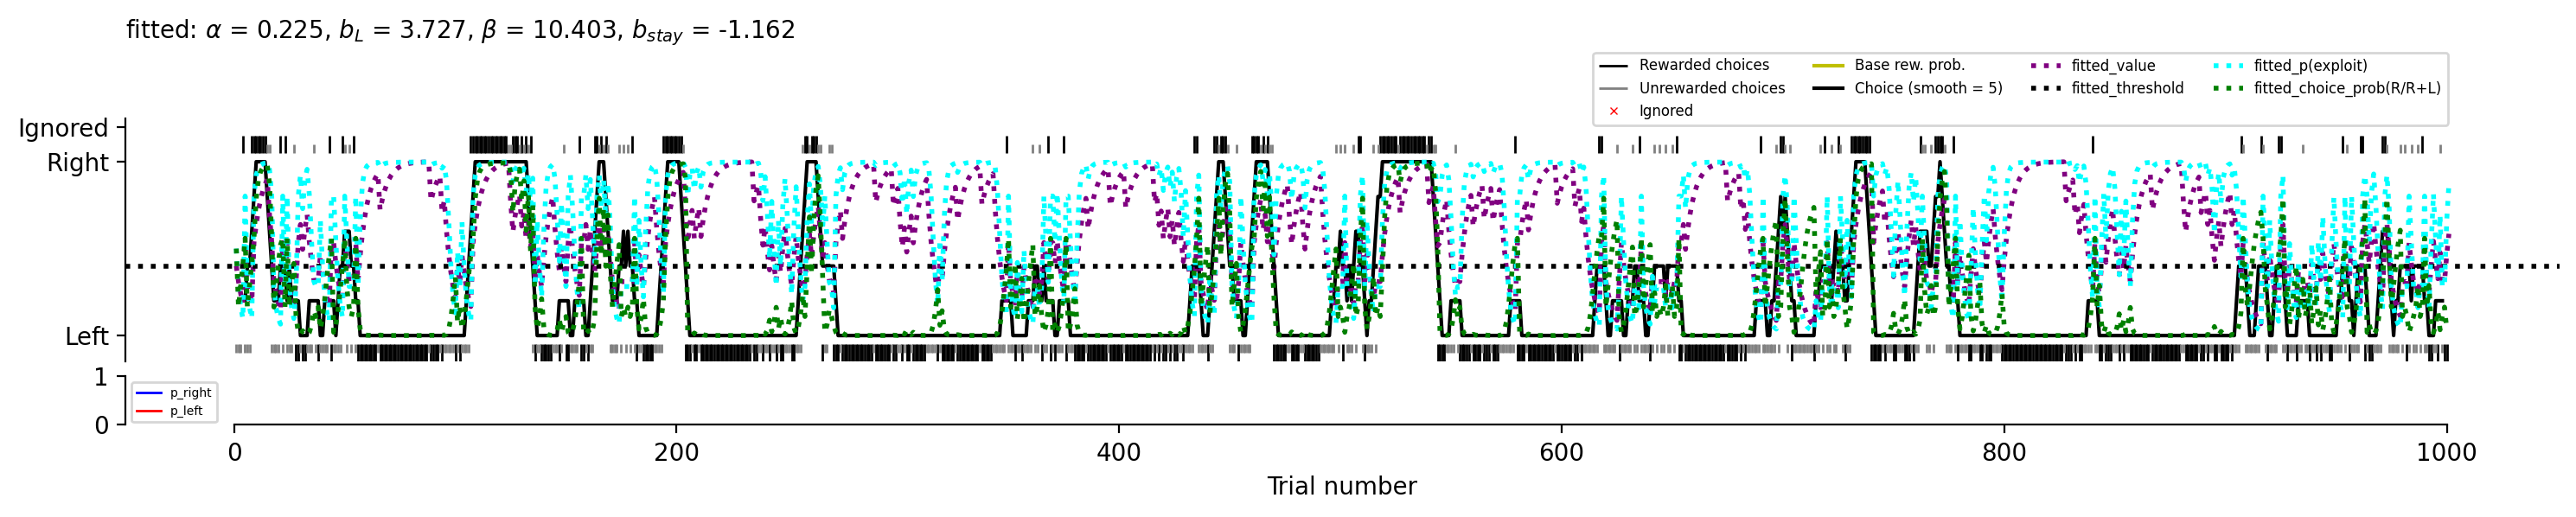

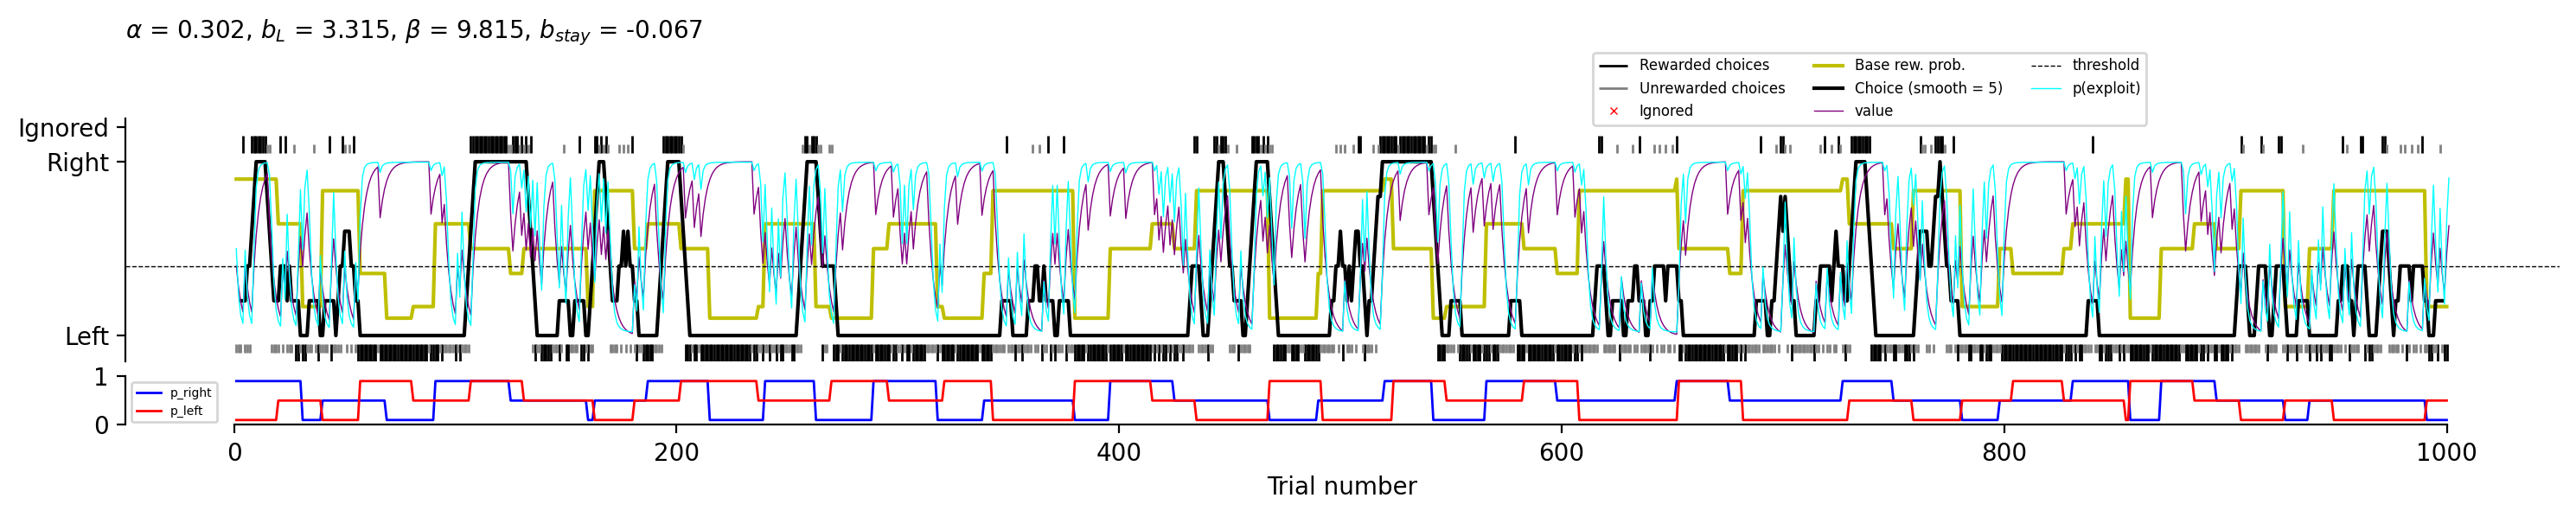

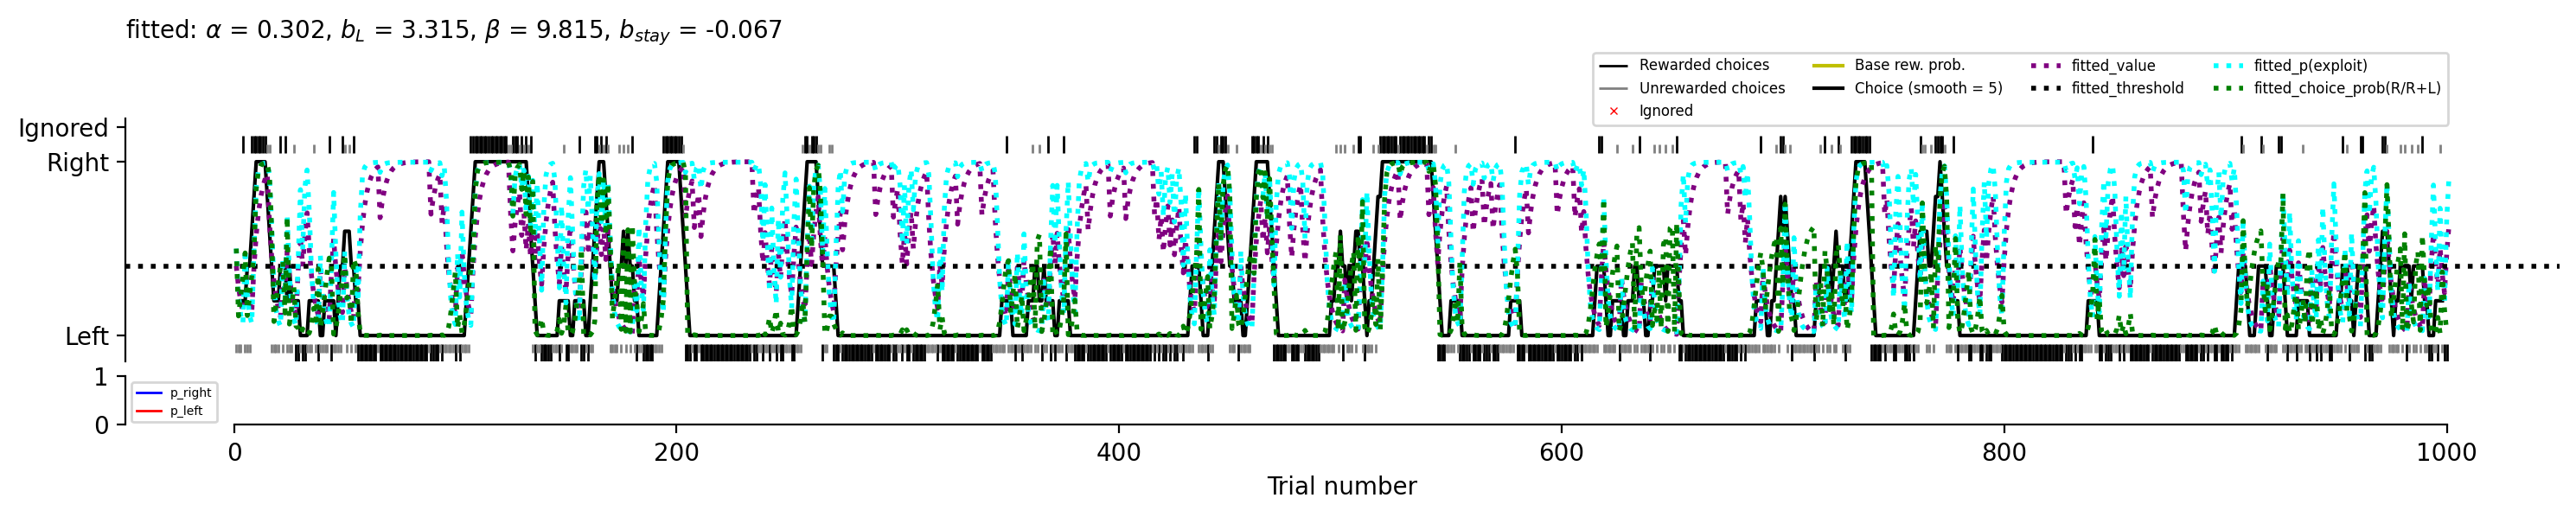

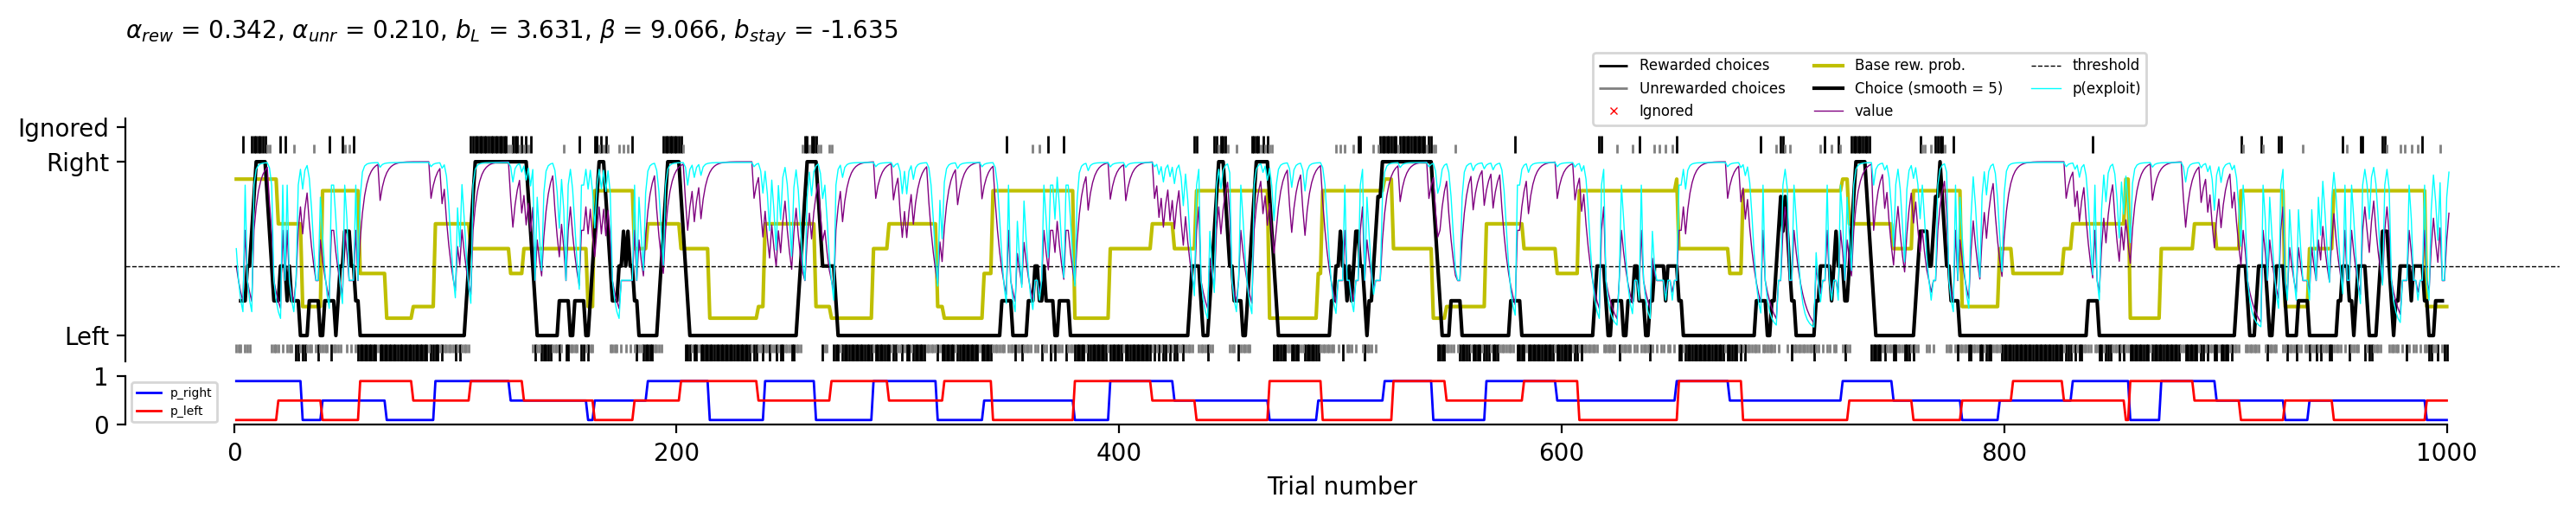

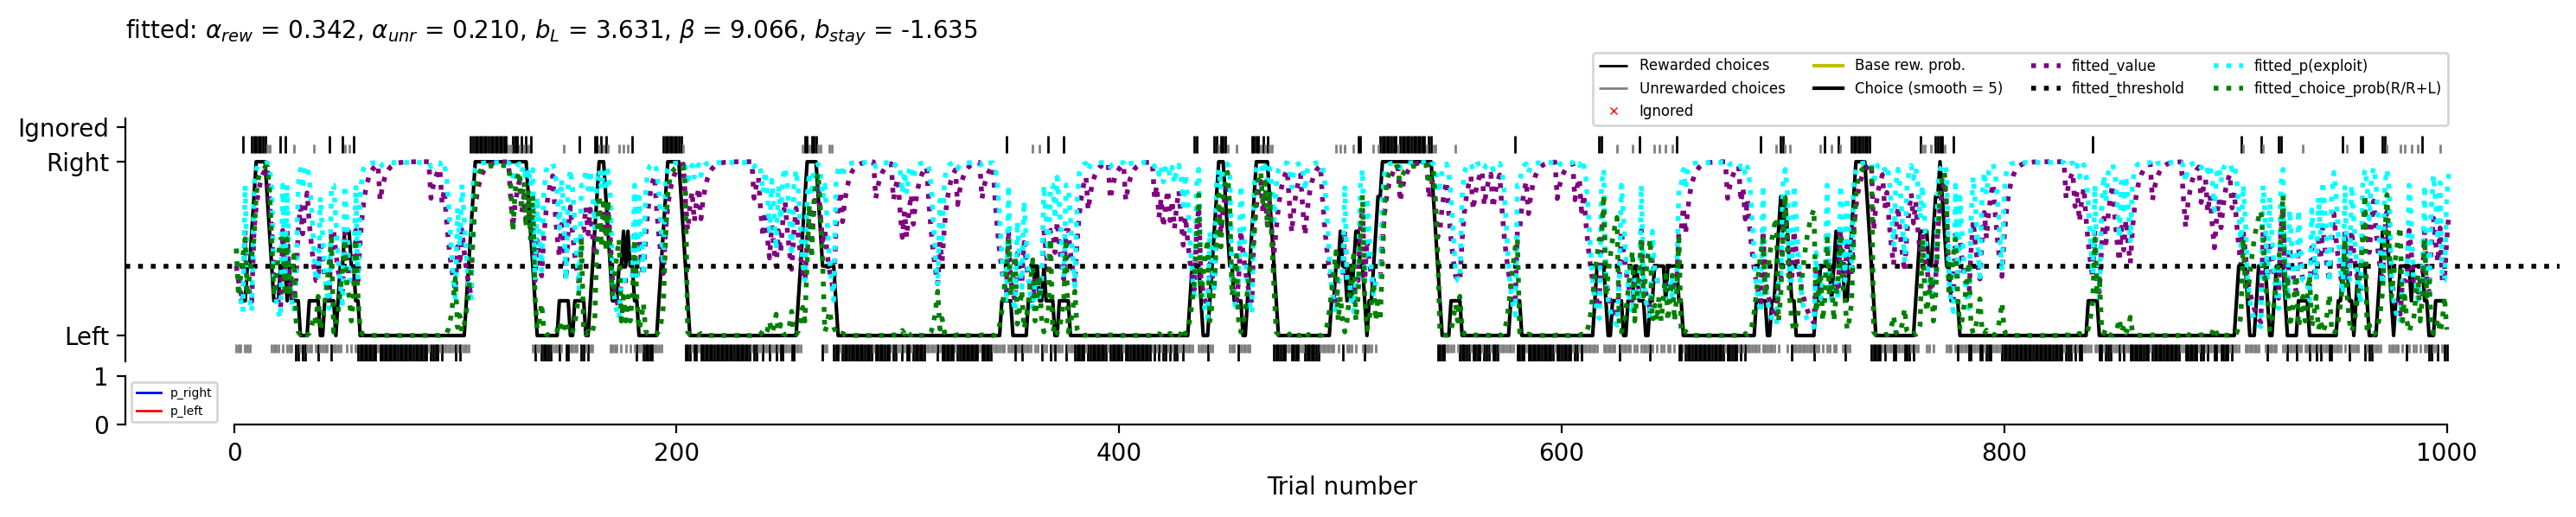

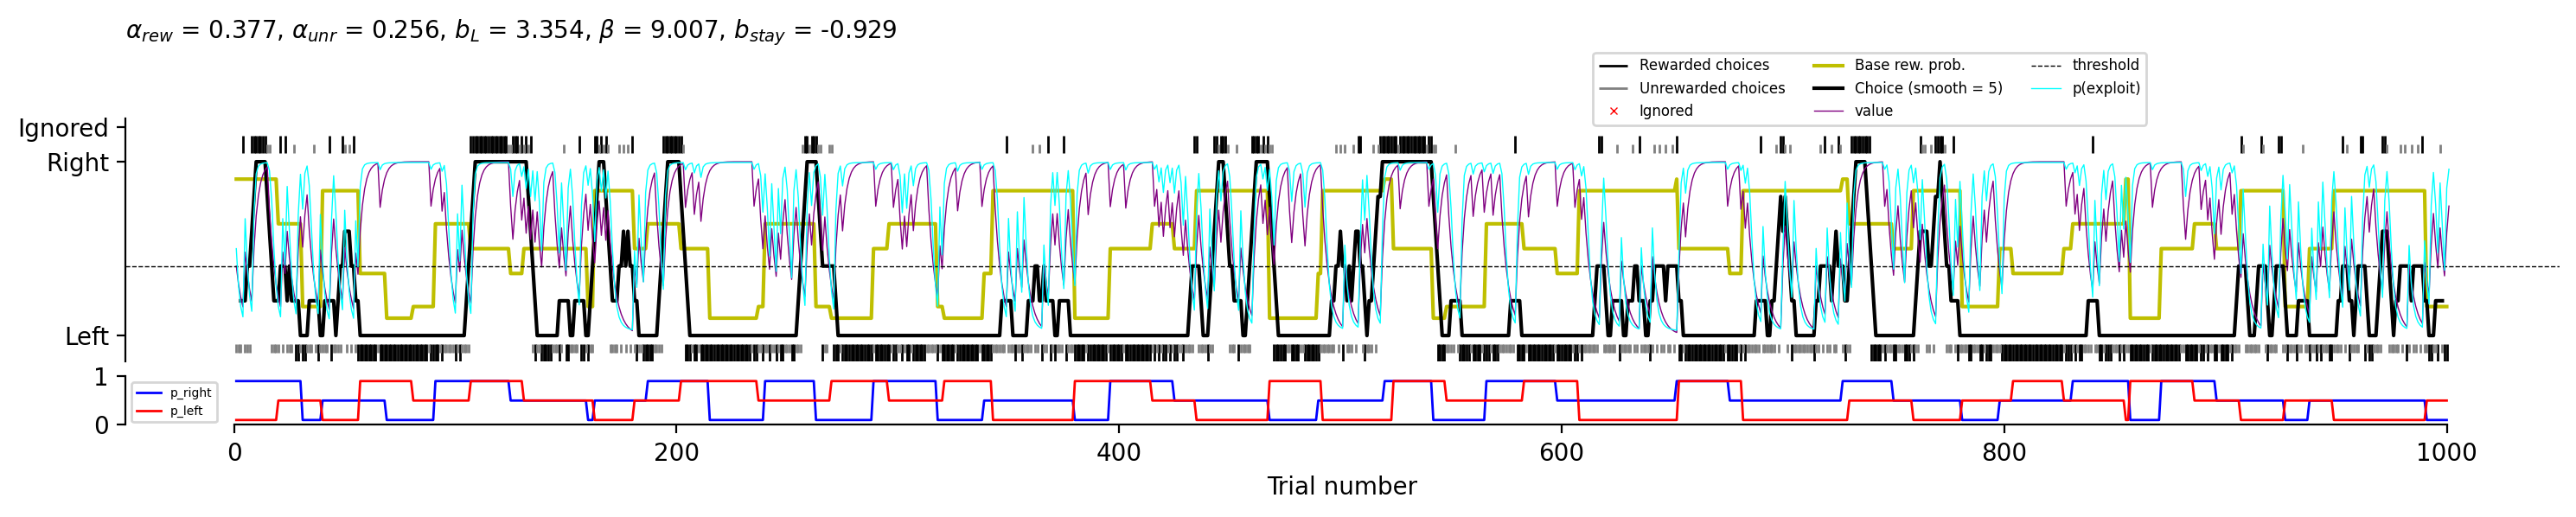

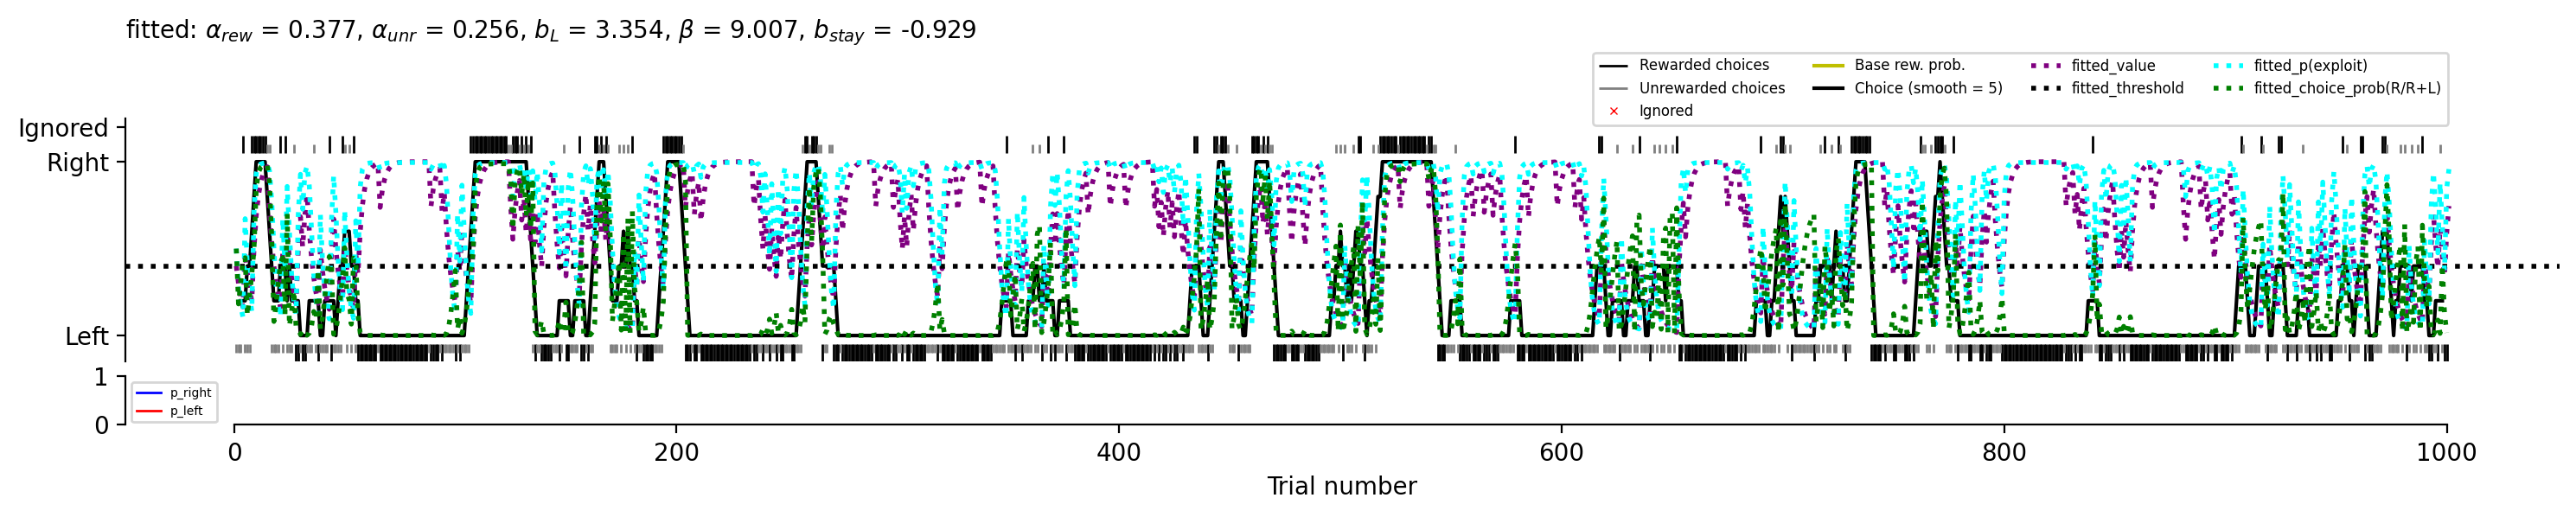

In [20]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1️⃣ Print Ground Truth Once
# --------------------------------------------------
print("\n================ GROUND TRUTH ================\n")
print(f"Ground-truth agent: {forager_gen.get_agent_alias()}")
print(f"Ground-truth params: {ground_truth_params}")
print("\n")


# --------------------------------------------------
# 2️⃣ Plot sessions for ALL fitted variants
# --------------------------------------------------
task_for_plot = forager_gen.task

for r in results:
    agent = r["agent"]
    agent.task = task_for_plot

    print("\n" + "-" * 80)
    print(f"Plotting fitted variant: {r['agent_alias']}")
    fig_fit, axes_fit = agent.plot_session(if_plot_latent=True)

    fig_fitting, axes = agent.plot_fitted_session(if_plot_latent=True)
# --------------------------------------------------
# 3️⃣ Build Comparison DataFrame
# --------------------------------------------------
rows = []

# First collect all possible parameter names across models
all_param_names = set()
for r in results:
    fit_names = r["agent"].fitting_result.fit_settings["fit_names"]
    all_param_names.update(fit_names)

all_param_names = sorted(all_param_names)

# ---- Ground Truth Row ----
gt_row = {
    "agent_alias": "GROUND_TRUTH",
    "number_of_learning_rate": GT_number_of_learning_rate,
    "reset_to_threshold": GT_reset_to_threshold,
    "LPT": np.nan,
    "prediction_accuracy": np.nan,
}

for name in all_param_names:
    if name in ground_truth_params:
        gt_row[f"Fit_{name}"] = ground_truth_params[name]
    else:
        gt_row[f"Fit_{name}"] = np.nan

rows.append(gt_row)


# ---- Fitted Model Rows ----
for r in results:
    agent = r["agent"]
    fr = agent.fitting_result

    row = {
        "agent_alias": r["agent_alias"],
        "number_of_learning_rate": r["number_of_learning_rate"],
        "reset_to_threshold": r["reset_to_threshold"],
        "LPT": float(fr.LPT),
        "prediction_accuracy": float(fr.prediction_accuracy),
    }

    fit_names = fr.fit_settings["fit_names"]

    for name in all_param_names:
        if name in fit_names:
            idx = fit_names.index(name)
            row[f"Fit_{name}"] = float(fr.x[idx])
        else:
            row[f"Fit_{name}"] = np.nan

    rows.append(row)


comparison_df = (
    pd.DataFrame(rows)
    .sort_values("LPT", ascending=False, na_position="first")
    .reset_index(drop=True)
)

comparison_df
